<div class="alert alert-block alert-info" align=center><h1>Crafting a Story from NTSB accident data</h1></div>

<div class="alert alert-block alert-info"> <strong>The data comes from the NTSB site. </strong><br><br>
The search criteria for this notebook is <br><br>
Query text: [<br>
	(EventDate) is on or after (2000-01-01)<br>
	And<br>
	(AircraftCategory) is (AIR)<br>
	And<br>
	(EngineType) is (TP)<br>
]<br><br>

Accidents of turbo prop airplaces since January 1st 2000. </div>

<div class="alert alert-block alert-info"><h2>Imports</h2></div>

In [2]:
!pip install contextily osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 74.2 MB/s eta 0:00:00


In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import contextily as ctx
import numpy as np
import osmnx as ox
import importlib
import nltk
import pyproj
import matplotlib.lines as mlines
import os
from nltk.corpus import stopwords
from shapely.geometry import Point
from scipy.stats import gaussian_kde
from geopy.distance import geodesic
from google.colab import drive
from IPython.display import HTML
from IPython.core.display import display, HTML
from IPython.display import Image, display


<div class="alert alert-block alert-info"><h2>Functions</h2></div>

In [4]:
def plot_top_accident_zones(top_10_gdf: gpd.GeoDataFrame, title: str = "Top 10 Highest Accident Density Locations in the US"):
    """
    Plots the top 10 accident zones on a map with a basemap.

    Args:
        top_10_gdf: GeoDataFrame containing the accident locations.
        title: Title of the plot. Defaults to "Top 10 Highest Accident Density Locations in the US".
    """
    # Convert back to lat/lon
    top_10_gdf = top_10_gdf.to_crs(epsg=4326)

    # Create a plot
    fig, ax = plt.subplots(figsize=(12, 7))

    # Plot the accident locations
    top_10_gdf.plot(ax=ax, color="red", markersize=100, alpha=0.8, label="Top 10 Accident Zones")

    # Add basemap
    ctx.add_basemap(ax, crs=top_10_gdf.crs, source=ctx.providers.CartoDB.Positron)

    # Automatically adjust x/y limits based on accident locations
    xmin, xmax = top_10_gdf.geometry.x.min() - 5, top_10_gdf.geometry.x.max() + 5
    ymin, ymax = top_10_gdf.geometry.y.min() - 5, top_10_gdf.geometry.y.max() + 5
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # Labels & Title
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title)
    ax.legend()

    plt.show()

In [5]:
def get_city_coordinates(df, city_name):
    """Retrieves the coordinates (longitude, latitude) of a city from the DataFrame."""
    city_data = df[df['City'] == city_name]
    if not city_data.empty:
        longitude = city_data.iloc[0]['Longitude']
        latitude = city_data.iloc[0]['Latitude']
        return (longitude, latitude)
    else:
        return None

In [6]:
def filter_accidents_within_radius(top_10_gdf, all_accidents_gdf, radius_km=50):
    """
    Filters accidents that fall within a given radius of the top 10 accident locations.

    Parameters:
    top_10_gdf (GeoDataFrame): A GeoDataFrame containing the top 10 accident locations.
    all_accidents_gdf (GeoDataFrame): A GeoDataFrame containing all accident locations.
    radius_km (float): The radius (in km) around each top accident location to filter other accidents.

    Returns:
    GeoDataFrame: A filtered GeoDataFrame with accidents within the radius.
    """
    # Ensure both datasets are in lat/lon for distance calculations
    top_10_gdf = top_10_gdf.to_crs(epsg=4326)
    all_accidents_gdf = all_accidents_gdf.to_crs(epsg=4326)

    # Remove empty geometries
    all_accidents_gdf = all_accidents_gdf.dropna(subset=["geometry"])
    all_accidents_gdf = all_accidents_gdf[all_accidents_gdf.geometry.notnull()]
    all_accidents_gdf = all_accidents_gdf[all_accidents_gdf.geometry.is_valid]

    # List to store filtered accidents
    filtered_accidents = []

    # Iterate over top 10 accident locations
    for _, top_row in top_10_gdf.iterrows():
        if top_row.geometry.is_empty:
            continue  # Skip empty locations

        top_point = (top_row.geometry.y, top_row.geometry.x)  # (lat, lon)

        # Filter accidents within the radius
        for _, accident_row in all_accidents_gdf.iterrows():
            if accident_row.geometry.is_empty:
                continue  # Skip empty points

            accident_point = (accident_row.geometry.y, accident_row.geometry.x)  # (lat, lon)
            if geodesic(top_point, accident_point).km <= radius_km:
                filtered_accidents.append(accident_row)

    # Create a new GeoDataFrame from the filtered accidents
    filtered_gdf = gpd.GeoDataFrame(filtered_accidents, crs="EPSG:4326")

    return filtered_gdf

In [7]:
def calculate_distances(tpa_gdf_4326, city_coords, crs_value):
    """Calculates distances from city to accident locations."""
    if not city_coords:
        print("City coordinates are missing!")
        return None

    city_point = Point(city_coords[0], city_coords[1])
    city_gs = gpd.GeoSeries([city_point], crs=tpa_gdf_4326.crs)

    # Ensure valid geometry before transformation
    if city_gs.is_empty.any():
        print("City geometry is empty! Skipping...")
        return None

    city_gs_utm = city_gs.to_crs(crs_value)
    tpa_gdf_utm = tpa_gdf_4326.to_crs(crs_value)

    # Ensure correct row alignment
    if len(city_gs_utm) == 0 or len(tpa_gdf_utm) == 0:
        print("Empty dataset after transformation! Skipping...")
        return None

    distance = tpa_gdf_utm.geometry.distance(city_gs_utm.geometry[0])
    meters_to_miles = 0.000621371
    distance_miles = distance * meters_to_miles

    return distance_miles.reset_index(drop=True)  #  Reset index to ensure alignment

In [8]:
def find_city_name(tpa_data, point):
    """Finds city name from tpa_data based on geometry using proximity."""
    if tpa_data.empty:
        return "Unknown City"

    min_distance = float('inf')
    closest_city = "Unknown City"

    for index, row in tpa_data.iterrows():
        if pd.isna(row['Longitude']) or pd.isna(row['Latitude']):
            continue  # Skip rows with missing coordinates

        current_point = Point(row['Longitude'], row['Latitude'])
        distance = point.distance(current_point)
        if distance < min_distance:
            min_distance = distance
            closest_city = row['City']

    return closest_city

In [9]:
def assign_city_names(top_10_gdf, tpa_gdf_4326):
    """Finds the closest city and state for each top accident location using a projected CRS."""

    # Convert to Projected CRS (Web Mercator)
    top_10_proj = top_10_gdf.to_crs(epsg=3857)
    tpa_proj = tpa_gdf_4326.to_crs(epsg=3857)

    # Perform spatial join in projected CRS
    top_10_with_city = gpd.sjoin_nearest(top_10_proj, tpa_proj[['City', 'State', 'geometry']], how="left", distance_col="dist_meters")

    # Convert back to lat/lon (EPSG:4326) for readability
    top_10_with_city = top_10_with_city.to_crs(epsg=4326)

    return top_10_with_city[['geometry', 'City', 'State', 'dist_meters']]

<div class="alert alert-block alert-info"><h2>Load the Data</h2></div>

In [10]:
drive.mount('/content/drive')
tpa_data = pd.read_csv("/content/drive/My Drive/SpringBoard/Data Files/cases2025-03-12_19-38.csv")

Mounted at /content/drive


In [11]:
tpa_data.head()

,NtsbNo,EventType,Mkey,EventDate,City,State,Country,ReportNo,N#,SerialNumber,...,FAR,AirCraftDamage,WeatherCondition,Operator,BroadPhaseofFlight,ReportStatus,RepGenFlag,MostRecentReportType,DocketUrl,ReportUrl
0,CEN25LA020,ACC,195351,2024-10-17T16:00:00Z,Addison,Texas,United States,NaN,N903SC,NCC-1701,...,091,Substantial,VMC,NaN,Unknown,Completed,NaN,Final,https://data.ntsb.gov/Docket?ProjectID=195351,https://data.ntsb.gov/carol-repgen/api/Aviatio...
1,CEN25LA008,ACC,195281,2024-10-08T14:00:00Z,Inguadona,Minnesota,United States,NaN,N212FB,802A-0368,...,137,Substantial,VMC,AERO SPRAY INC,Landing,Completed,NaN,Final,https://data.ntsb.gov/Docket?ProjectID=195281,https://data.ntsb.gov/carol-repgen/api/Aviatio...
2,WPR24LA300,ACC,195086,2024-08-31T14:40:00Z,Mulino,Oregon,United States,NaN,N902ST,153,...,091,Substantial,VMC,TRUE NORTH AVIATION LLC,Unknown,Completed,NaN,Final,https://data.ntsb.gov/Docket?ProjectID=195086,https://data.ntsb.gov/carol-repgen/api/Aviatio...
3,ERA24LA360,ACC,195017,2024-08-26T13:01:00Z,Jesup,Georgia,United States,NaN,N686AC,BE-127,...,091,Substantial,VMC,STM AIR LLC,Landing,Completed,NaN,Final,https://data.ntsb.gov/Docket?ProjectID=195017,https://data.ntsb.gov/carol-repgen/api/Aviatio...
4,ERA24LA354,ACC,194972,2024-08-19T08:58:00Z,Asheboro,North Carolina,United States,NaN,N600KA,FA-143,...,091,Substantial,VMC,NaN,Landing,Completed,NaN,Final,https://data.ntsb.gov/Docket?ProjectID=194972,https://data.ntsb.gov/carol-repgen/api/Aviatio...


In [12]:
tpa_data.shape

(2061, 46)

In [13]:
tpa_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2061 entries, 0 to 2060
Data columns (total 46 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   NtsbNo                       2061 non-null   object 
 1   EventType                    2061 non-null   object 
 2   Mkey                         2061 non-null   int64  
 3   EventDate                    2061 non-null   object 
 4   City                         2060 non-null   object 
 5   State                        1953 non-null   object 
 6   Country                      2058 non-null   object 
 7   ReportNo                     21 non-null     object 
 8   N#                           2061 non-null   object 
 9   SerialNumber                 2039 non-null   object 
 10  HasSafetyRec                 2061 non-null   bool   
 11  Mode                         2061 non-null   object 
 12  ReportType                   1965 non-null   object 
 13  OriginalPublishedD

In [14]:
tpa_data.describe()

,Mkey,FatalInjuryCount,SeriousInjuryCount,MinorInjuryCount,OnboardInjuryCount,OnGroundInjuryCount,EventID,Latitude,Longitude,RepGenFlag
count,2061.000000,2059.000000,2059.000000,2059.000000,2038.000000,1866.000000,0.0,1974.000000,1974.000000,0.0
mean,80525.382339,0.631374,0.152987,0.234094,0.998037,0.033226,NaN,37.645640,-551.244827,NaN
std,25828.628749,2.064463,0.597537,0.856339,2.348397,0.320807,NaN,11.104392,20133.590805,NaN
min,48434.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,-37.734443,-894627.000000,NaN
25%,61307.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,33.221935,-111.764307,NaN
50%,77953.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,37.493333,-95.340141,NaN
75%,94577.000000,0.000000,0.000000,0.000000,1.000000,0.000000,NaN,42.202423,-85.664375,NaN
max,195351.000000,50.000000,9.000000,19.000000,49.000000,9.000000,NaN,72.300834,151.220550,NaN


In [15]:
tpa_data.isnull().sum()

,0
NtsbNo,0
EventType,0
Mkey,0
EventDate,0
City,1
State,108
Country,3
ReportNo,2040
N#,0
SerialNumber,22


In [16]:
tpa_data = tpa_data.drop('EventID',axis=1)

In [17]:
# Select columns with object data type (strings)
object_cols = tpa_data.select_dtypes(include=['object']).columns

# Identify columns containing URLs
url_cols = [col for col in object_cols if tpa_data[col].astype(str).str.contains('http').any()]

# Drop the URL columns
tpa_data = tpa_data.drop(url_cols, axis=1)

In [18]:
tpa_data.shape

(2061, 42)

In [19]:
tpa_data['WeatherCondition'].unique()

array(['VMC', 'IMC', 'Unknown', nan], dtype=object)

In [20]:
tpa_data.columns

Index(['NtsbNo', 'EventType', 'Mkey', 'EventDate', 'City', 'State', 'Country',
       'ReportNo', 'N#', 'SerialNumber', 'HasSafetyRec', 'Mode', 'ReportType',
       'OriginalPublishedDate', 'DocketOriginalPublishedDate',
       'HighestInjuryLevel', 'FatalInjuryCount', 'SeriousInjuryCount',
       'MinorInjuryCount', 'OnboardInjuryCount', 'OnGroundInjuryCount',
       'Findings', 'Latitude', 'Longitude ', 'Make', 'Model',
       'AirCraftCategory', 'AirportID', 'AirportName', 'AmateurBuilt',
       'NumberOfEngines', 'EngineType', 'Scheduled', 'PurposeOfFlight', 'FAR',
       'AirCraftDamage', 'WeatherCondition', 'Operator', 'BroadPhaseofFlight',
       'ReportStatus', 'RepGenFlag', 'MostRecentReportType'],
      dtype='object')

In [21]:
# Remove trailing (and leading) spaces from column names
tpa_data.columns = tpa_data.columns.str.strip()

<div class="alert alert-block alert-info"> <strong>We will plot the Event locations on a map.</strong><br>
    Could there be a geo related story we can find?</div>

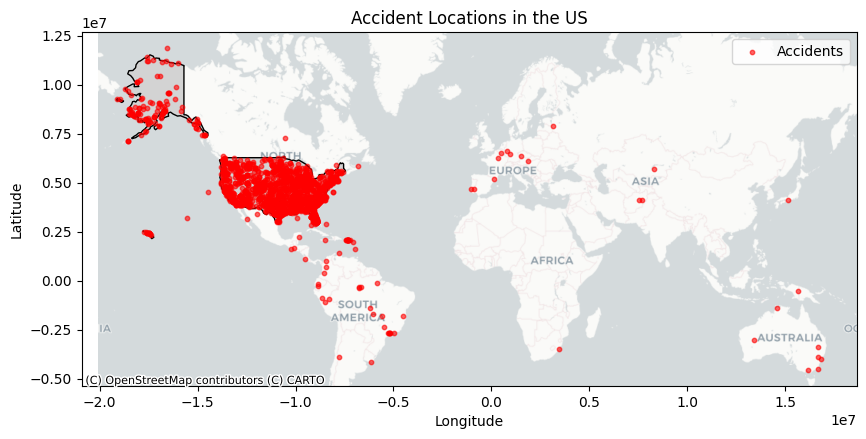

In [22]:
# Download the Natural Earth dataset manually or use a direct link
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# Download the Natural Earth dataset manually or use a direct link
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# Filter for the United States
us_map = world[world["ADMIN"] == "United States of America"]

# Convert accident data to a GeoDataFrame
geometry = gpd.points_from_xy(tpa_data['Longitude'], tpa_data['Latitude'])
tpa_gdf = gpd.GeoDataFrame(tpa_data, geometry=geometry, crs="EPSG:4326")

# Ensure the US map and accident data have consistent projections
us_map = us_map.to_crs(epsg=3857)
tpa_gdf = tpa_gdf.to_crs(epsg=3857)

# Plot the map
fig, ax = plt.subplots(figsize=(10, 6))
us_map.plot(ax=ax, color="lightgrey", edgecolor="black")
tpa_gdf.plot(ax=ax, color="red", markersize=10, alpha=0.6, label="Accidents")

# Add base map
ctx.add_basemap(ax, crs=tpa_gdf.crs, source=ctx.providers.CartoDB.Positron)


# Labels and title
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Accident Locations in the US")
ax.legend()

plt.show()



<div class="alert alert-block alert-info"> This was not very helpful.<br>
    The goal was to see if certain types of terrains have no accident<br>
    Next, we will check if accident count is tied to terrain.
</div>

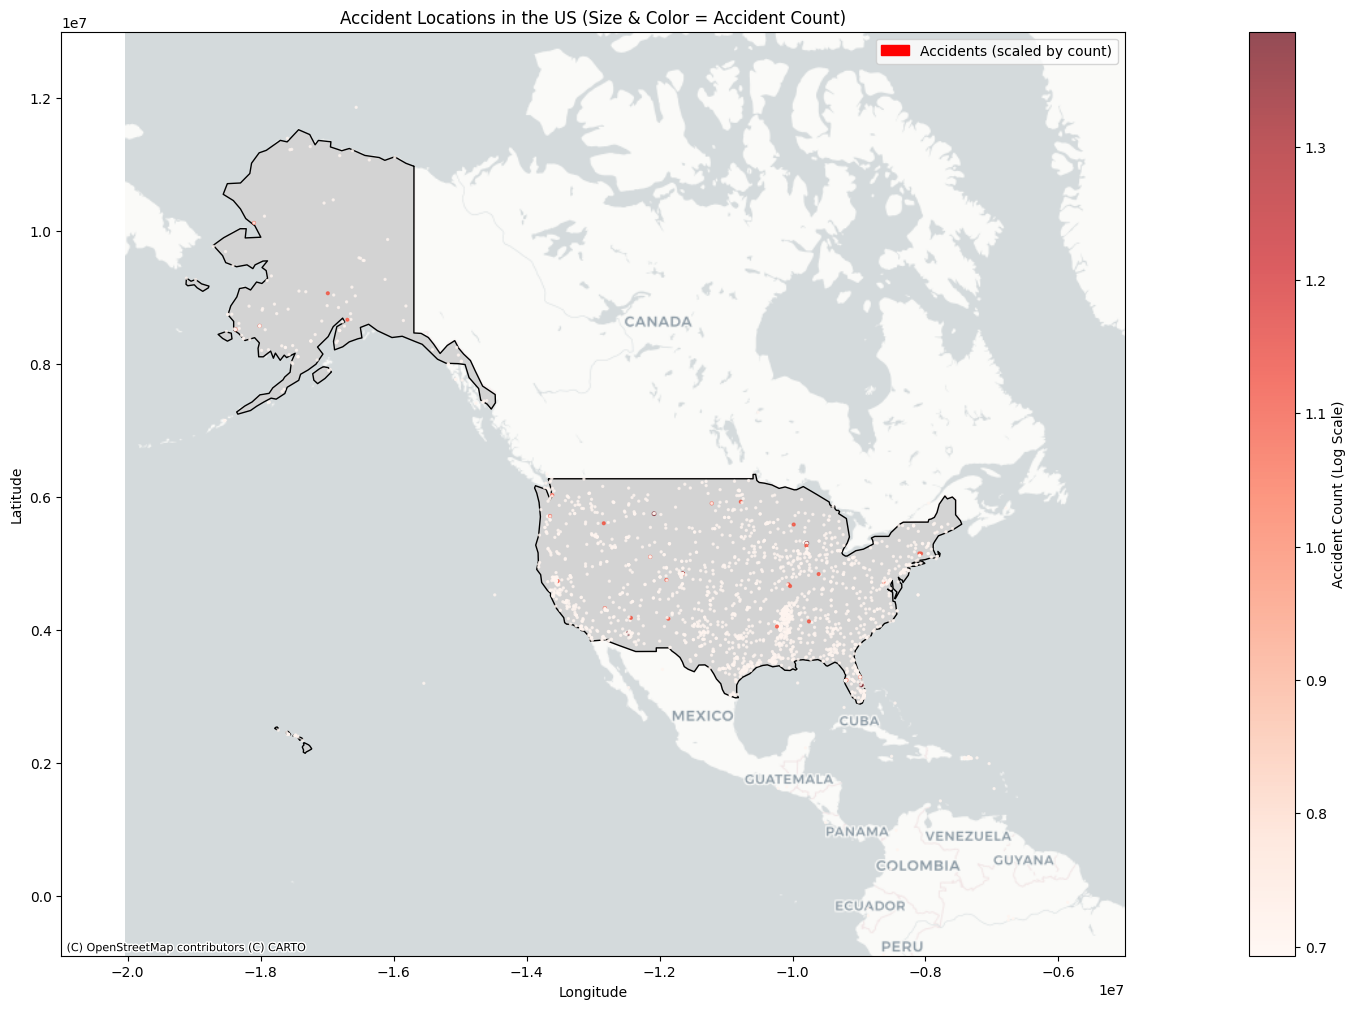

In [23]:
# Ensure consistent projections
us_map = us_map.to_crs(epsg=3857)
tpa_gdf = tpa_gdf.to_crs(epsg=3857)

# Drop invalid geometries
tpa_gdf = tpa_gdf.dropna(subset=["geometry"])
tpa_gdf = tpa_gdf[tpa_gdf.is_valid]

# Aggregate accident count per location
tpa_gdf["count"] = 1
accident_counts = tpa_gdf.groupby("geometry").size().reset_index(name="count")

# Convert 'geometry' column to a GeoDataFrame
accident_counts = gpd.GeoDataFrame(accident_counts, geometry="geometry", crs="EPSG:3857")

# Drop NaN values in 'geometry' after grouping
accident_counts = accident_counts.dropna(subset=["geometry"])
accident_counts = accident_counts[accident_counts.is_valid]

# Define size and color scaling
accident_counts["size"] = accident_counts["count"] * 2  # Adjust size for better visibility
accident_counts["color"] = np.log1p(accident_counts["count"])  # Log scale for better color mapping

# Define bounding box for North America (EPSG:3857)
north_america_bounds = (-21000000, -900000, -5000000, 13000000)

# Plot the map
fig, ax = plt.subplots(figsize=(32, 12))
us_map.plot(ax=ax, color="lightgrey", edgecolor="black")

# Extract X and Y coordinates properly
x_coords = accident_counts.geometry.x
y_coords = accident_counts.geometry.y

# Plot accidents with improved visualization
sc = ax.scatter(
    x_coords,
    y_coords,
    s=accident_counts["size"],
    c=accident_counts["color"],
    cmap="Reds",  # Use Reds colormap
    alpha=0.7,  # Increase transparency for better density view
    edgecolors=None  # Remove black outlines
)

# Set limits to focus on North America
ax.set_xlim(north_america_bounds[0], north_america_bounds[2])
ax.set_ylim(north_america_bounds[1], north_america_bounds[3])

# Add the basemap
ctx.add_basemap(ax, crs=tpa_gdf.crs, source=ctx.providers.CartoDB.Positron)

# Add colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Accident Count (Log Scale)")

# Labels and title
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Accident Locations in the US (Size & Color = Accident Count)")

# Manually add a legend with reference sizes
import matplotlib.patches as mpatches
legend_patch = mpatches.Patch(color="red", label="Accidents (scaled by count)")
ax.legend(handles=[legend_patch], loc="upper right")

plt.show()

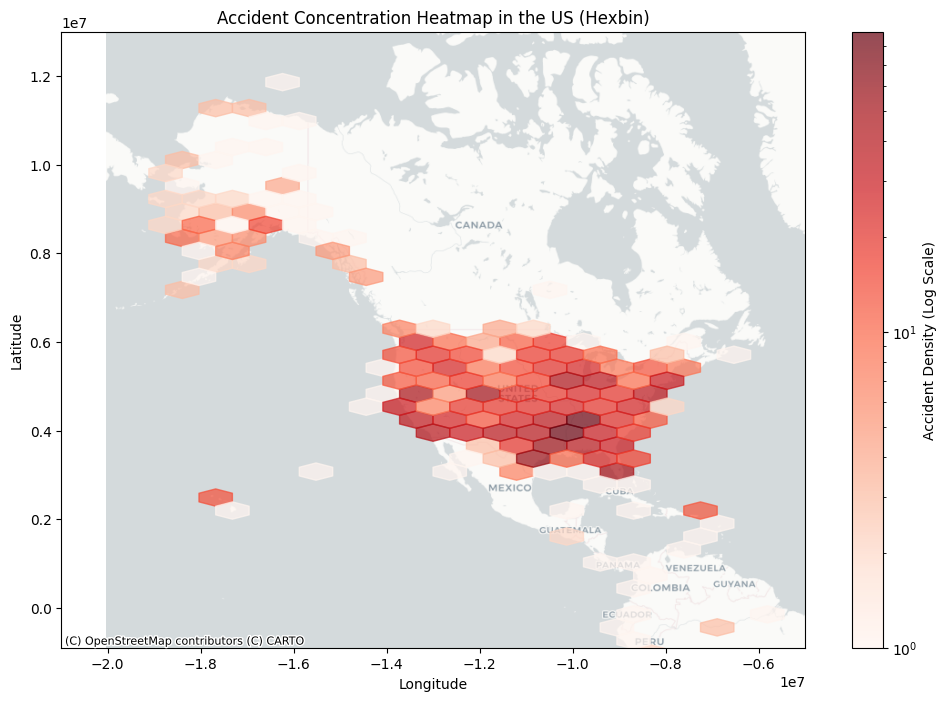

In [24]:
# Ensure CRS is correct
tpa_gdf = tpa_gdf.to_crs(epsg=3857)

# Drop NaN and invalid geometries
tpa_gdf = tpa_gdf.dropna(subset=["geometry"])
tpa_gdf = tpa_gdf[tpa_gdf.is_valid]

# Extract X and Y coordinates
x_coords = tpa_gdf.geometry.x
y_coords = tpa_gdf.geometry.y

# Drop NaN & Infinite Values
valid_mask = (~np.isnan(x_coords)) & (~np.isnan(y_coords)) & (~np.isinf(x_coords)) & (~np.isinf(y_coords))
x_coords, y_coords = x_coords[valid_mask], y_coords[valid_mask]

# Ensure valid data exists
if len(x_coords) == 0 or len(y_coords) == 0:
    print("No valid accident coordinates found! Check projection and data.")
else:
    # Plot Hexbin Map
    fig, ax = plt.subplots(figsize=(12, 8))

    # Hexbin scatter plot
    hb = ax.hexbin(
        x_coords, y_coords, gridsize=50, cmap="Reds", bins="log", alpha=0.7
    )

    # Add colorbar
    cbar = plt.colorbar(hb, ax=ax)
    cbar.set_label("Accident Density (Log Scale)")

    # Set limits to focus on North America
    ax.set_xlim(north_america_bounds[0], north_america_bounds[2])
    ax.set_ylim(north_america_bounds[1], north_america_bounds[3])

    # Add basemap
    ctx.add_basemap(ax, crs="EPSG:3857", source=ctx.providers.CartoDB.Positron)

    # Labels & Title
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Accident Concentration Heatmap in the US (Hexbin)")

    plt.show()

In [25]:
# Ensure CRS is correct
tpa_gdf = tpa_gdf.to_crs(epsg=3857)

# Drop NaN and invalid geometries
tpa_gdf = tpa_gdf.dropna(subset=["geometry"])
tpa_gdf = tpa_gdf[tpa_gdf.is_valid]

# Extract X and Y coordinates
x_coords = tpa_gdf.geometry.x
y_coords = tpa_gdf.geometry.y

# Drop NaN & Infinite Values
valid_mask = (~x_coords.isna()) & (~y_coords.isna()) & (~x_coords.isin([np.inf, -np.inf])) & (~y_coords.isin([np.inf, -np.inf]))
x_coords, y_coords = x_coords[valid_mask], y_coords[valid_mask]

# Create a 2D histogram (hexbin-like count data)
hb_counts, x_edges, y_edges = np.histogram2d(x_coords, y_coords, bins=60)

# Compute bin centers
x_centers = (x_edges[:-1] + x_edges[1:]) / 2
y_centers = (y_edges[:-1] + y_edges[1:]) / 2

# Flatten count data and create DataFrame
hexbin_data = pd.DataFrame({
    "x": np.repeat(x_centers, len(y_centers)),
    "y": np.tile(y_centers, len(x_centers)),
    "count": hb_counts.flatten()
})

# Remove zero-count bins
hexbin_data = hexbin_data[hexbin_data["count"] > 0]

# Get the top 10 highest accident density locations
top_10_hexes = hexbin_data.nlargest(10, "count")

In [26]:
# Convert the top 10 locations back to EPSG:4326 (lat/lon)
top_10_gdf = gpd.GeoDataFrame(top_10_hexes, geometry=gpd.points_from_xy(top_10_hexes["x"], top_10_hexes["y"]), crs="EPSG:3857")
top_10_gdf = top_10_gdf.to_crs(epsg=4326)

tpa_gdf_4326 = gpd.GeoDataFrame(tpa_data, geometry=geometry, crs='EPSG:4326')

# Find closest cities
closest_cities = gpd.sjoin_nearest(top_10_gdf, tpa_gdf_4326[['City', 'State','geometry']], how='left', rsuffix='_city')

# Inspect the columns of closest_cities
print(closest_cities.columns)




# Run the function and print results
top_10_gdf = assign_city_names(top_10_gdf, tpa_gdf_4326)

# Display the results
top_10_gdf

Index(['x', 'y', 'count', 'geometry', 'index__city', 'City', 'State'], dtype='object')


/usr/local/lib/python3.11/dist-packages/geopandas/array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


,geometry,City,State,dist_meters
932,POINT (-88.30461 36.31281),Paris,Tennessee,12126.452769
869,POINT (-93.6872 30.1553),Beaumont,Texas,49824.677080
931,POINT (-88.30461 34.3088),Tupelo,Mississippi,46044.089533
573,POINT (-120.60014 38.2666),Jackson,California,26676.983473
871,POINT (-93.6872 34.3088),Hot Springs,Arkansas,72227.379166
754,POINT (-104.45238 40.16922),Greeley,Colorado,44037.924676
988,POINT (-82.92202 28.0091),Clearwater,Florida,27816.398358
935,POINT (-88.30461 42.01996),West Chicago,Illinois,22911.174337
810,POINT (-99.06979 32.2558),Coleman,Texas,61861.996786
809,POINT (-99.06979 30.1553),New Braunfels,Texas,69861.641631


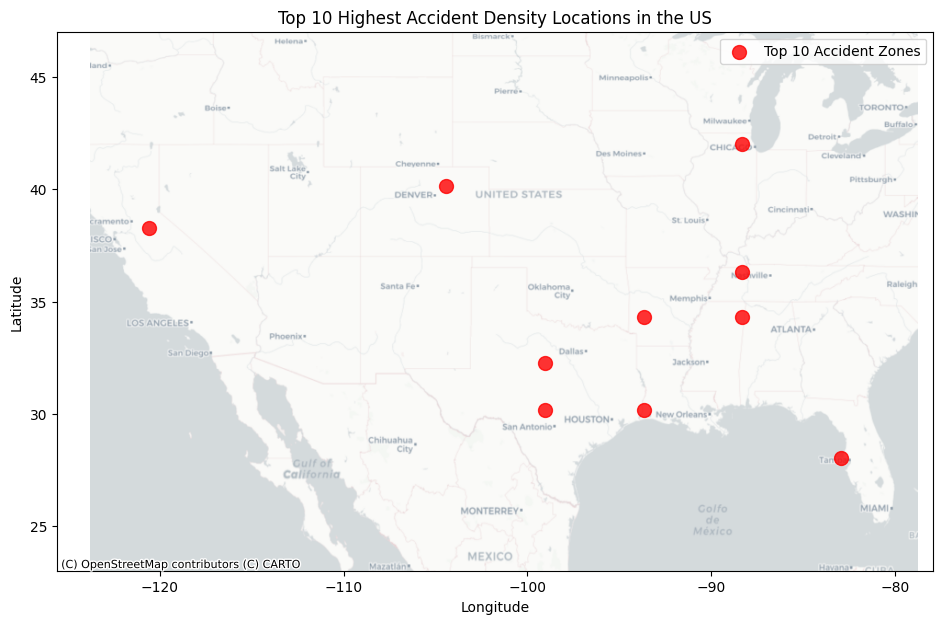

In [27]:
plot_top_accident_zones(top_10_gdf)

<div class="alert alert-block alert-info"> Are there specific turbo pro planes that are more prone to accident?<br>
</div>

In [28]:
# Value counts for Aircraft Make and Model (Thresholded)
make_counts = tpa_data['Make'].value_counts()
make_counts_filtered = make_counts[make_counts > 20]  # Filter for counts > 20

model_counts = tpa_data['Model'].value_counts()
model_counts_filtered = model_counts[model_counts > 20]

print("Aircraft Make Counts (Thresholded):\n", make_counts_filtered)
print("\nAircraft Model Counts (Thresholded):\n", model_counts_filtered)

# Group by Make and Model, then count accidents (Thresholded)
make_model_counts = tpa_data.groupby(['Make', 'Model']).size().sort_values(ascending=False)
make_model_counts_filtered = make_model_counts[make_model_counts > 20]

print("\nAccidents by Make and Model (Thresholded):\n", make_model_counts_filtered)

# Aircraft Category and Engine Type (No Threshold Needed)
print("\nAircraft Category Counts:\n", tpa_data['AirCraftCategory'].value_counts())
print("\nEngine Type Counts:\n", tpa_data['EngineType'].value_counts())

Aircraft Make Counts (Thresholded):
 Make
AIR TRACTOR INC                   179
Air Tractor                       167
Beech                             159
BEECH                             149
CESSNA                            117
Cessna                             94
PIPER                              75
AIR TRACTOR                        61
Ayres                              57
Piper                              54
SOCATA                             39
AYRES CORPORATION                  33
Mitsubishi                         31
de Havilland                       28
GRUMMAN ACFT ENG COR-SCHWEIZER     24
DEHAVILLAND                        23
Swearingen                         23
ROCKWELL INTERNATIONAL             22
Grumman                            22
Name: count, dtype: int64

Aircraft Model Counts (Thresholded):
 Model
208B           100
AT-502B         57
G-164B          55
208             52
AT-602          49
200             45
AT-502          40
S2R-T34         34
S2R          

<div class="alert alert-block alert-info"> Is a particular phase of flight more prevalent?
</div>

In [29]:
# Value counts for BroadPhaseofFlight
phase_counts = tpa_data['BroadPhaseofFlight'].value_counts()
print("\nAccidents by Phase of Flight:\n", phase_counts)


Accidents by Phase of Flight:
 BroadPhaseofFlight
Maneuvering             292
Landing                 275
Enroute                 203
Takeoff                 157
Approach                139
Initial Climb           103
Taxi                     51
Unknown                  23
Standing                 19
Emergency Descent         5
Uncontrolled Descent      4
After Landing             1
Post-Impact               1
Name: count, dtype: int64


<div class="alert alert-block alert-info">What can the findings tell us?<br>
</div>

In [30]:
total_accidents = len(tpa_data)

# Keyword searches in the Findings column (Thresholded and Sorted)
weather_terms = ["fog", "icing", "wind shear", "thunderstorm", "turbulence", "visibility", "weather"]
weather_counts = {}
for term in weather_terms:
    weather_accidents = tpa_data[tpa_data['Findings'].str.contains(term, case=False, na=False)]
    count = len(weather_accidents)
    if count > 10:  # Apply threshold
        percentage = (count / total_accidents) * 100
        weather_counts[term] = (count, percentage)

# Sort weather counts in descending order
sorted_weather_counts = dict(sorted(weather_counts.items(), key=lambda item: item[1][0], reverse=True))

print("\nWeather-Related Findings (Count and % of Total):\n")
for term, (count, percentage) in sorted_weather_counts.items():
    print(f"{term}: {count} ({percentage:.2f}%)")

#Other Factors
pilot_error_terms = ["pilot error", "loss of control", "stall", "improper procedure", "decision making"]
pilot_error_counts = {}
for term in pilot_error_terms:
    pilot_error_accidents = tpa_data[tpa_data['Findings'].str.contains(term, case=False, na=False)]
    count = len(pilot_error_accidents)
    if count > 10:
        percentage = (count / total_accidents) * 100
        pilot_error_counts[term] = (count, percentage)

# Sort pilot error counts in descending order
sorted_pilot_error_counts = dict(sorted(pilot_error_counts.items(), key=lambda item: item[1][0], reverse=True))

print("\nPilot Error-Related Findings (Count and % of Total):\n")
for term, (count, percentage) in sorted_pilot_error_counts.items():
    print(f"{term}: {count} ({percentage:.2f}%)")

mechanical_terms = ["engine failure", "mechanical failure", "maintenance", "component failure", "propeller"]
mechanical_counts = {}
for term in mechanical_terms:
    mechanical_accidents = tpa_data[tpa_data['Findings'].str.contains(term, case=False, na=False)]
    count = len(mechanical_accidents)
    if count > 5:
        percentage = (count / total_accidents) * 100
        mechanical_counts[term] = (count, percentage)

# Sort mechanical counts in descending order
sorted_mechanical_counts = dict(sorted(mechanical_counts.items(), key=lambda item: item[1][0], reverse=True))

print("\nMechanical-Related Findings (Count and % of Total):\n")
for term, (count, percentage) in sorted_mechanical_counts.items():
    print(f"{term}: {count} ({percentage:.2f}%)")


Weather-Related Findings (Count and % of Total):

weather: 258 (12.52%)
visibility: 73 (3.54%)
turbulence: 29 (1.41%)
icing: 13 (0.63%)
thunderstorm: 11 (0.53%)

Pilot Error-Related Findings (Count and % of Total):

decision making: 162 (7.86%)
stall: 19 (0.92%)

Mechanical-Related Findings (Count and % of Total):

maintenance: 91 (4.42%)
propeller: 15 (0.73%)


In [31]:
# Download stopwords (if not already downloaded)
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

total_accidents = len(tpa_data)

# Remove stop words and punctuation, and filter out non-alphabetic tokens
stop_words = set(stopwords.words('english'))

# Initialize a dictionary to store counts
findings_counts = {}

# Iterate through each finding
for finding in tpa_data['Findings'].dropna():  # Drop NaN values
    words = [word for word in finding.lower().split() if word.isalpha() and word not in stop_words]
    for word in set(words): # Use set to count each word only once per finding.
        if word in findings_counts:
            findings_counts[word] += 1
        else:
            findings_counts[word] = 1

# Convert dictionary to Series
findings_counts = pd.Series(findings_counts)

# Filter for counts > 10
findings_counts_filtered = findings_counts[findings_counts > 10]

# Calculate percentages
findings_percentages = (findings_counts_filtered / total_accidents) * 100

# Combine counts and percentages into a DataFrame
findings_df = pd.DataFrame({'count': findings_counts_filtered, 'percentage': findings_percentages})

# Sort by count in descending order
findings_df_sorted = findings_df.sort_values(by='count', ascending=False)

# Display top 5
print("\nTop 5 Highest Count Findings (and Percentages):\n")
for term, row in findings_df_sorted.head(5).iterrows():
    print(f"{term}: {int(row['count'])} ({row['percentage']:.2f}%)")


Top 5 Highest Count Findings (and Percentages):

issues: 998 (48.42%)
aircraft: 931 (45.17%)
personnel: 899 (43.62%)
performance: 592 (28.72%)
task: 571 (27.70%)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


<div class="alert alert-block alert-info">We have a lot of data points for our story<br>
    Let us dive deeper into the top 10 US locations for accidents.<br>
    Our focus is Turbo Prop airplanes
</div>

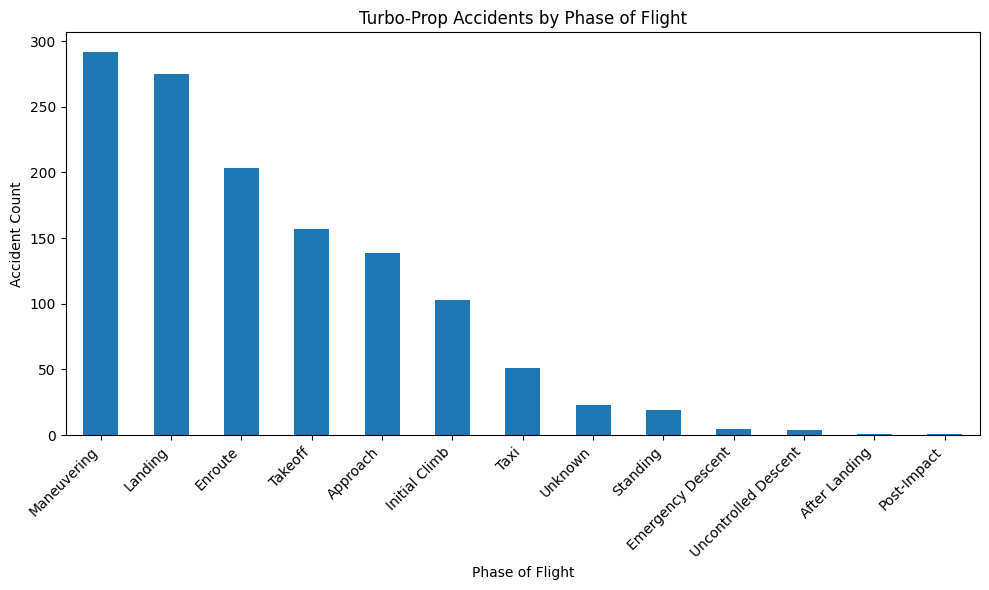

In [33]:

plt.figure(figsize=(10, 6))  # Adjust figure size as needed

phase_counts.plot(kind='bar') # or kind='barh' for a horizontal bar chart
plt.xlabel("Phase of Flight")
plt.ylabel("Accident Count")
plt.title("Turbo-Prop Accidents by Phase of Flight")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

In [35]:
top_10_gdf

,geometry,City,State,dist_meters
932,POINT (-88.30461 36.31281),Paris,Tennessee,12126.452769
869,POINT (-93.6872 30.1553),Beaumont,Texas,49824.677080
931,POINT (-88.30461 34.3088),Tupelo,Mississippi,46044.089533
573,POINT (-120.60014 38.2666),Jackson,California,26676.983473
871,POINT (-93.6872 34.3088),Hot Springs,Arkansas,72227.379166
754,POINT (-104.45238 40.16922),Greeley,Colorado,44037.924676
988,POINT (-82.92202 28.0091),Clearwater,Florida,27816.398358
935,POINT (-88.30461 42.01996),West Chicago,Illinois,22911.174337
810,POINT (-99.06979 32.2558),Coleman,Texas,61861.996786
809,POINT (-99.06979 30.1553),New Braunfels,Texas,69861.641631


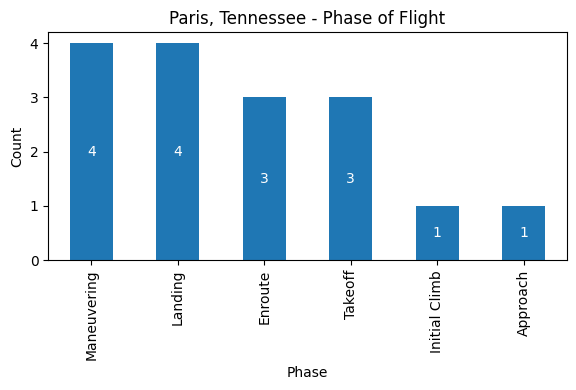

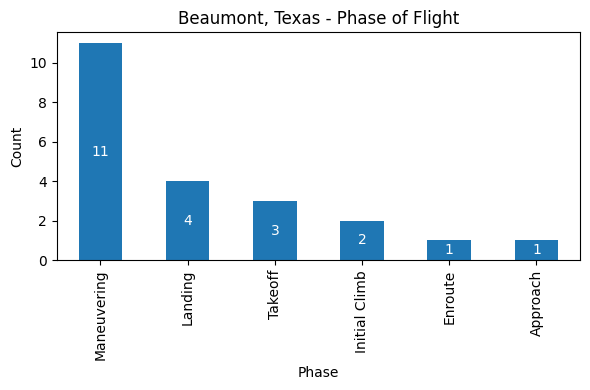

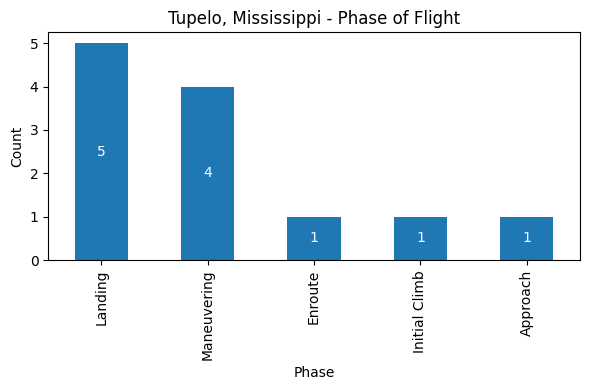

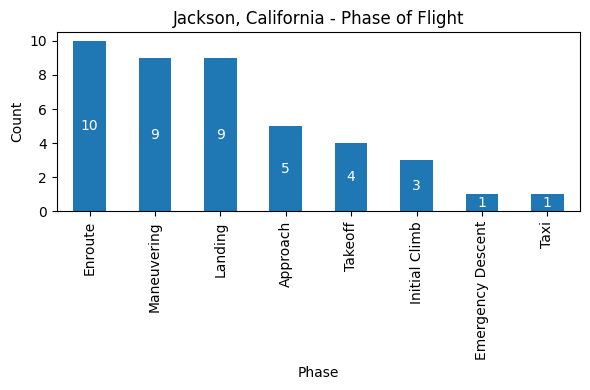

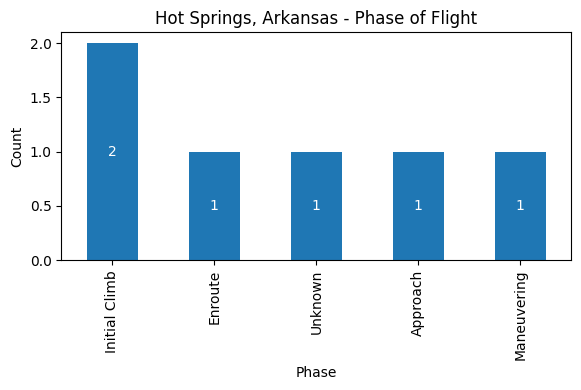

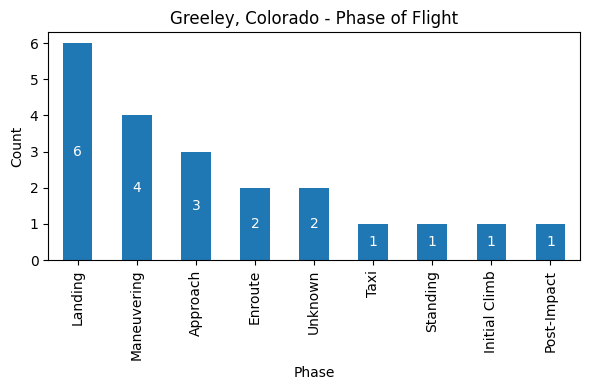

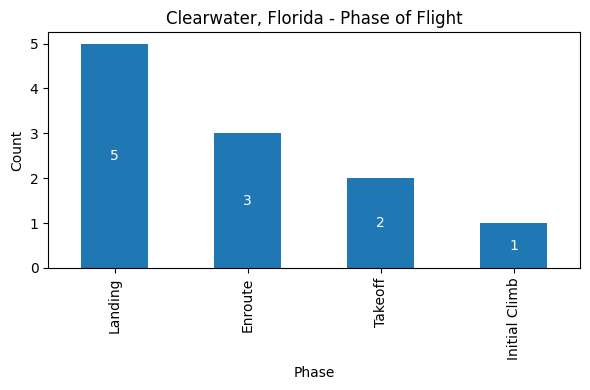

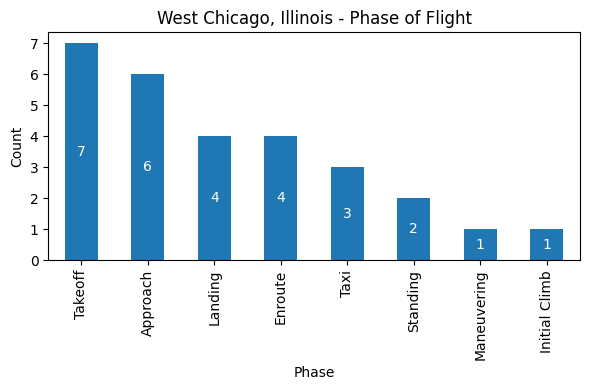

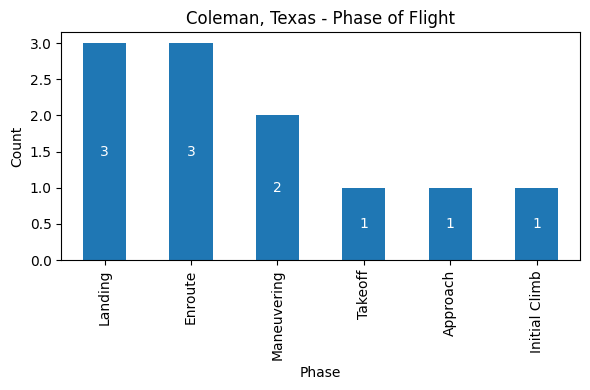

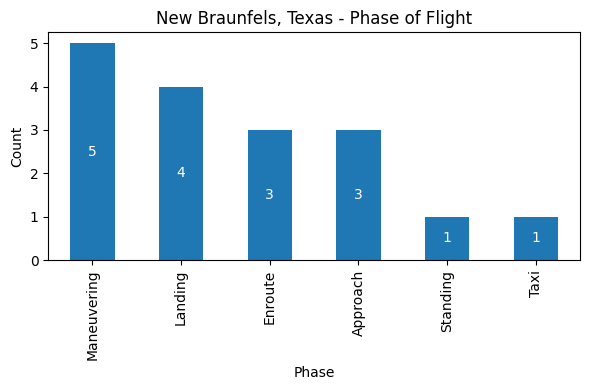

In [36]:
# Create GeoDataFrame from tpa_data if not already created.
if 'tpa_gdf_4326' not in locals():
    tpa_data_clean = tpa_data.dropna(subset=['Longitude', 'Latitude'])
    tpa_data_clean = tpa_data_clean[~tpa_data_clean['Longitude'].isin([None, np.inf, -np.inf])]
    tpa_data_clean = tpa_data_clean[~tpa_data_clean['Latitude'].isin([None, np.inf, -np.inf])]
    geometry = [Point(lon, lat) for lon, lat in zip(tpa_data_clean['Longitude'], tpa_data_clean['Latitude'])]
    tpa_gdf_4326 = gpd.GeoDataFrame(tpa_data_clean, geometry=geometry, crs='EPSG:4326')

for index, row in top_10_gdf.iterrows():
    city_name = row['City']
    city_coords = (row.geometry.x, row.geometry.y)
    state_name = row['State']

    # Calculate UTM zone and CRS
    utm_zone = int((city_coords[0] + 180) / 6) + 1
    crs_value = f'EPSG:{26900 + utm_zone}'

    # Calculate distances
    distance_miles = calculate_distances(tpa_gdf_4326, city_coords, crs_value)

    if distance_miles is not None:
        # Reindex distance_miles to match tpa_gdf_4326 index
        distance_miles = distance_miles.reindex(tpa_gdf_4326.index)

        # Filter by distance (100 miles)
        region_data = tpa_gdf_4326[distance_miles <= 100]

        if not region_data.empty:
            # Analyze phase of flight for the filtered regions
            phase_counts = region_data['BroadPhaseofFlight'].value_counts()


            # Visualization
            plt.figure(figsize=(6, 4))
            bars = phase_counts.plot(kind='bar')
            plt.title(f"{city_name}, {state_name} - Phase of Flight")
            plt.xlabel("Phase")
            plt.ylabel("Count")
            plt.tight_layout()
             # Add count labels on top of bars
            for bar in bars.patches:
                yval = bar.get_height()
                plt.text(bar.get_x() + bar.get_width() / 2, yval / 2, round(yval, 2), ha='center', va='center', color='white', fontsize=10)

            plt.show()
        else:
            print(f"No accidents found within 100 miles of {city_name}.")
    else:
        print(f"Error calculating distances for {city_name}")

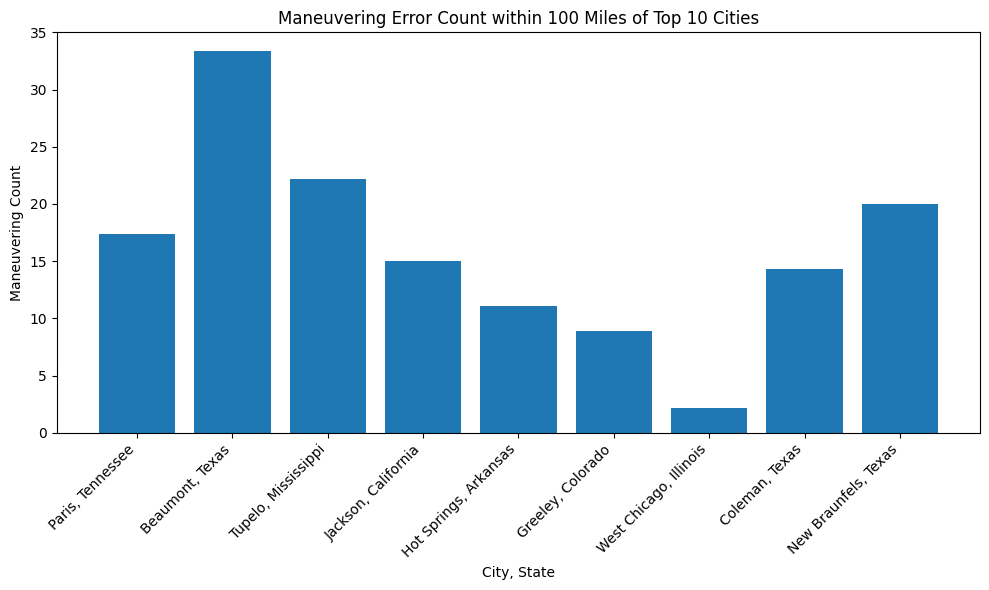

In [92]:
# Create a list to store the results for each city
maneuvering_results = []

for index, row in top_10_gdf.iterrows():
    city_name = row['City']
    city_coords = (row.geometry.x, row.geometry.y)
    state_name = row['State']

    # Calculate UTM zone and CRS
    utm_zone = int((city_coords[0] + 180) / 6) + 1
    crs_value = f'EPSG:{26900 + utm_zone}'

    # Calculate distances
    distance_miles = calculate_distances(tpa_gdf_4326, city_coords, crs_value)

    if distance_miles is not None:
        # Reindex distance_miles to match tpa_gdf_4326 index
        distance_miles = distance_miles.reindex(tpa_gdf_4326.index)


        # Filter by distance (100 miles)
        region_data = tpa_gdf_4326[distance_miles <= 100]

        if not region_data.empty:
            # Analyze Maneuvering phase of flight
            maneuvering_data = region_data[region_data['BroadPhaseofFlight'] == 'Maneuvering']

            if not maneuvering_data.empty:
                # Count occurrences of Maneuvering
                maneuvering_count = len(maneuvering_data)
                total_count = len(region_data)

                # Store the results in the list
                maneuvering_results.append({
                    'City': city_name,
                    'State': state_name,
                    'Maneuvering Incidents': maneuvering_count,
                    'Total Incidents': total_count,
                    'Maneuvering Percentage': (maneuvering_count / total_count) * 100
                })

# Create a DataFrame from the results
maneuvering_df = pd.DataFrame(maneuvering_results)

if not maneuvering_df.empty:
    # Visualization (Optional: Bar chart of Maneuvering percentages)
    plt.figure(figsize=(10, 6))
    plt.bar(maneuvering_df['City'].astype(str) + ', ' + maneuvering_df['State'].astype(str), maneuvering_df['Maneuvering Percentage'])
    plt.xlabel('City, State')
    plt.ylabel('Maneuvering Count')
    plt.title('Maneuvering Error Count within 100 Miles of Top 10 Cities')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No Maneuvering incidents were found within 100 miles of the top 10 accident locations.")

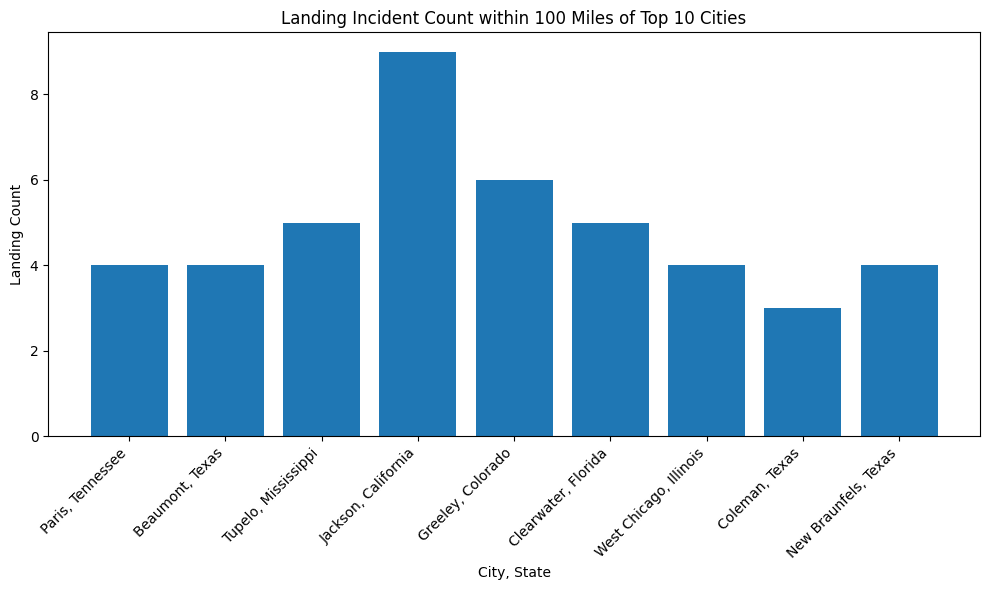

In [69]:
landing_results = []
state_total_incidents_from_landing = {}

for index, row in top_10_gdf.iterrows():
    city_name = row['City']
    city_coords = (row.geometry.x, row.geometry.y)
    state_name = row['State']

    # Calculate UTM zone and CRS
    utm_zone = int((city_coords[0] + 180) / 6) + 1
    crs_value = f'EPSG:{26900 + utm_zone}'

    # Calculate distances
    distance_miles = calculate_distances(tpa_gdf_4326, city_coords, crs_value)

    if distance_miles is not None:
        # Reindex distance_miles to match tpa_gdf_4326 index
        distance_miles = distance_miles.reindex(tpa_gdf_4326.index)

        # Filter by distance (100 miles)
        region_data = tpa_gdf_4326[distance_miles <= 100]

        if not region_data.empty:
            # Store the total incidents for this region
            if state_name not in state_total_incidents_from_landing:
                state_total_incidents_from_landing[state_name] = 0
            state_total_incidents_from_landing[state_name] += len(region_data)

            # Analyze Landing phase of flight
            landing_data = region_data[region_data['BroadPhaseofFlight'] == 'Landing']

            if not landing_data.empty:
                # Count occurrences of Landing (numerator)
                landing_count = len(landing_data)

                # Calculate Total Landing Incidents in the Region (denominator)
                total_landing_incidents_in_region = len(region_data[region_data['BroadPhaseofFlight'] == 'Landing'])

                # Store the results in the list
                landing_results.append({
                    'City': city_name,
                    'State': state_name,
                    'Landing Incidents': landing_count,
                    'Landing Percentage': (landing_count / total_landing_incidents_in_region) * 100 if total_landing_incidents_in_region > 0 else 0
                })

# Create a DataFrame from the results
landing_df = pd.DataFrame(landing_results)

if not landing_df.empty:
    # Visualization (Bar chart of Landing Counts)
    plt.figure(figsize=(10, 6))
    plt.bar(landing_df['City'].astype(str) + ', ' + landing_df['State'].astype(str), landing_df['Landing Incidents'])
    plt.xlabel('City, State')
    plt.ylabel('Landing Count')
    plt.title('Landing Incident Count within 100 Miles of Top 10 Cities')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No Landing incidents were found within 100 miles of the top 10 accident locations.")

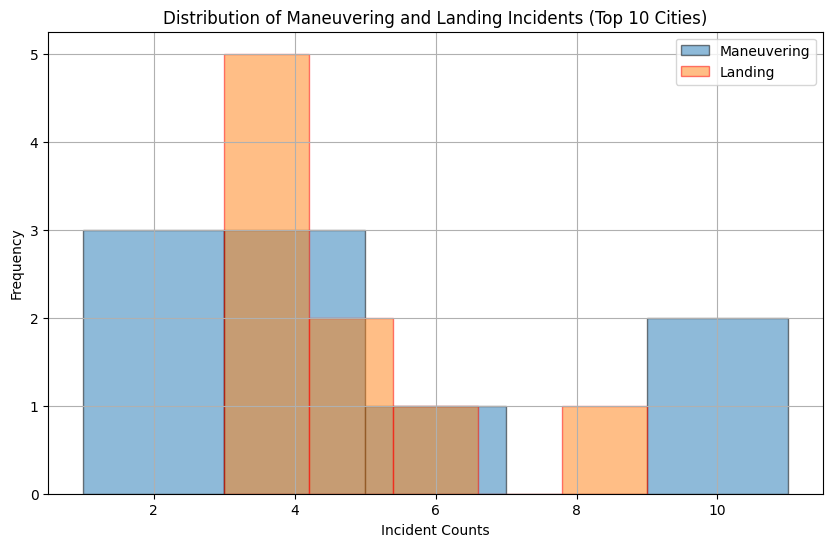

In [62]:
if not maneuvering_df.empty and not landing_df.empty:
    # Extract Maneuvering and Landing counts
    maneuvering_counts = maneuvering_df['Maneuvering Incidents']
    landing_counts = landing_df['Landing Incidents']

    # Create overlaid histograms
    plt.figure(figsize=(10, 6))
    plt.hist(maneuvering_counts, bins=5, alpha=0.5, label='Maneuvering', edgecolor='black')
    plt.hist(landing_counts, bins=5, alpha=0.5, label='Landing', edgecolor='red')
    plt.xlabel('Incident Counts')
    plt.ylabel('Frequency')
    plt.title('Distribution of Maneuvering and Landing Incidents (Top 10 Cities)')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()
else:
    print("One or both dataframes are empty, no histogram can be created.")

In [64]:
landing_df

,City,State,Landing Incidents,Landing Percentage
0,Paris,Tennessee,4,17.391304
1,Beaumont,Texas,4,12.121212
2,Tupelo,Mississippi,5,27.777778
3,Jackson,California,9,15.000000
4,Greeley,Colorado,6,13.333333
5,Clearwater,Florida,5,25.000000
6,West Chicago,Illinois,4,8.510638
7,Coleman,Texas,3,21.428571
8,New Braunfels,Texas,4,16.000000


In [63]:
maneuvering_df

,City,State,Maneuvering Incidents,Total Incidents,Maneuvering Percentage
0,Paris,Tennessee,4,23,17.391304
1,Beaumont,Texas,11,33,33.333333
2,Tupelo,Mississippi,4,18,22.222222
3,Jackson,California,9,60,15.000000
4,Hot Springs,Arkansas,1,9,11.111111
5,Greeley,Colorado,4,45,8.888889
6,West Chicago,Illinois,1,47,2.127660
7,Coleman,Texas,2,14,14.285714
8,New Braunfels,Texas,5,25,20.000000


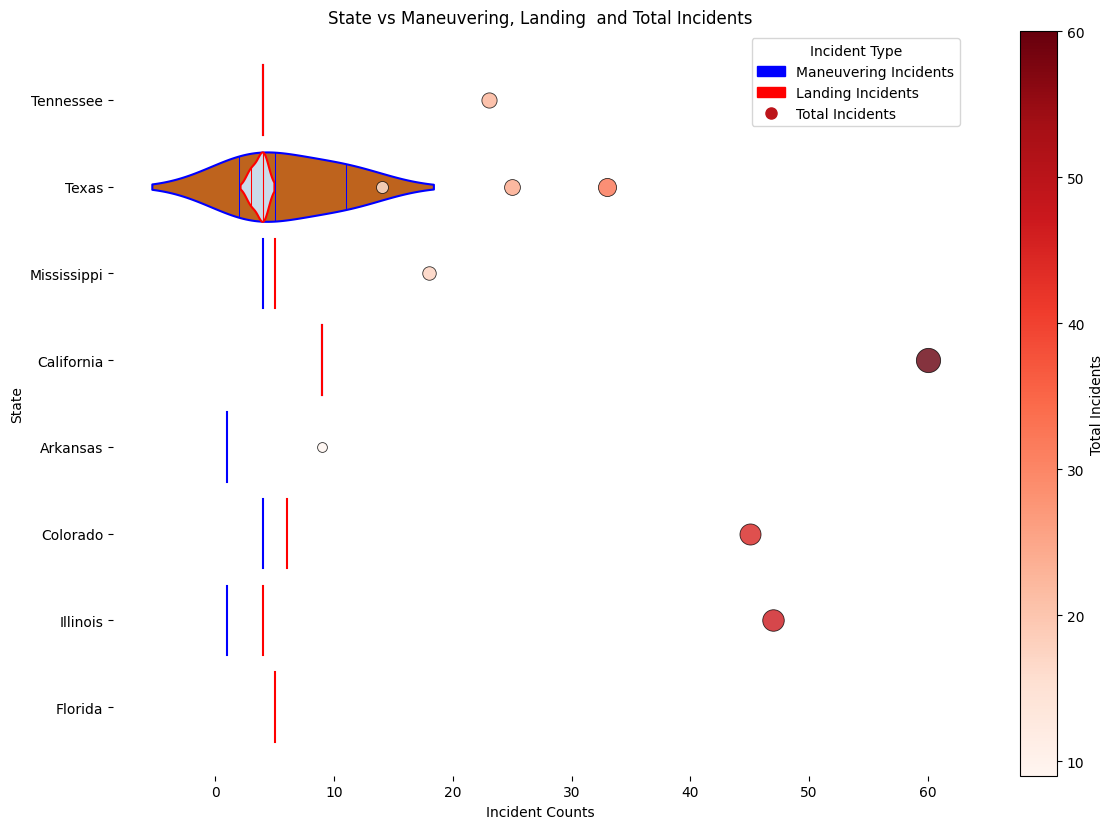

In [58]:
# State vs Maneuvering & Landing Incidents and Total Incidents

figsize = (12, 1.2 * maneuvering_df['State'].nunique())  # Example definition
fig, ax = plt.subplots(figsize=figsize)  # Explicitly define the figure and axis

# Violin plot for Maneuvering Incidents and Landing Incidents
# Maneuvering Incidents (e.g., Dark2 with Black Edge)
sns.violinplot(maneuvering_df, x='Maneuvering Incidents', y='State', hue='State',
               inner='stick', palette='Dark2', ax=ax, legend=False,
               linewidth=1.5, edgecolor='blue')

# Landing Incidents (e.g., Blues with Red Edge)
sns.violinplot(landing_df, x='Landing Incidents', y='State', hue='State',
               inner='stick', palette='Blues', ax=ax, legend=False,
               linewidth=1.5, edgecolor='red')

# Create legend handles manually
maneuvering_patch = mpatches.Patch(color='blue', label='Maneuvering Incidents')  # Adjust color if needed
landing_patch = mpatches.Patch(color='red', label='Landing Incidents')  # Adjust color if needed

# Scatter plot legend (Total Incidents)
scatter_legend = mlines.Line2D([], [],color=plt.cm.Reds(0.8), marker='o', linestyle='None', markersize=8, label='Total Incidents')

# Combine all into one legend
ax.legend(handles=[maneuvering_patch, landing_patch, scatter_legend],
          title="Incident Type", loc='upper right', frameon=True)

# Normalize colors and sizes based on Total Incidents
total_incident_counts = maneuvering_df['Total Incidents']
norm = plt.Normalize(total_incident_counts.min(), total_incident_counts.max())  # Normalize for color scale
sizes = 50 + (total_incident_counts - total_incident_counts.min()) * 5  # Scale sizes

# Create the scatter plot with color gradient and size variation
for index, row in maneuvering_df.iterrows():
    state = row['State']
    total_incidents = row['Total Incidents']
    center_x = np.median(maneuvering_df[maneuvering_df['State'] == state]['Maneuvering Incidents'])

    plt.scatter(total_incidents, state,
                color=plt.cm.Reds(norm(total_incidents)),  # Color based on incidents
                s=sizes.iloc[index],  # Size based on incidents
                alpha=0.8, edgecolors='black', linewidth=0.6,
                label="Total Incidents" if index == 0 else "")

# Labels & Cleanup
plt.xlabel('Incident Counts')
plt.ylabel('State')
plt.title('State vs Maneuvering, Landing  and Total Incidents')
sns.despine(top=True, right=True, bottom=True, left=True)
#plt.legend()
sm = plt.cm.ScalarMappable(cmap='Reds', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label="Total Incidents")
plt.tight_layout()
plt.show()


In [116]:
# Aggregate Maneuvering Data by State
maneuvering_state_agg = maneuvering_df.groupby('State').agg(
    Total_Maneuvering_Incidents=('Maneuvering Incidents', 'sum'),
    State_Total_Incidents=('Total Incidents', 'sum')
).reset_index()

# Calculate Maneuvering Percentage at the State Level
maneuvering_state_agg['Maneuvering_Percentage'] = round((
    (maneuvering_state_agg['Total_Maneuvering_Incidents'] / maneuvering_state_agg['State_Total_Incidents']) * 100
).fillna(0),2)

# Aggregate Landing Data by State
landing_state_agg = landing_df.groupby('State').agg(
    Total_Landing_Incidents=('Landing Incidents', 'sum')
).reset_index()


# Merge the two aggregated DataFrames on 'State'
state_level_df = pd.merge(maneuvering_state_agg, landing_state_agg, on='State', how='outer').fillna(0)
state_level_df['Total_Landing_Incidents'] = state_level_df['Total_Landing_Incidents'].astype(int)  # Force integer

# Update State_Total_Incidents with the correct values from landing analysis
state_level_df['State_Total_Incidents'] = state_level_df['State'].map(state_total_incidents_from_landing).fillna(state_level_df['State_Total_Incidents'])

# Calculate Landing Percentage
state_level_df['Landing_Percentage'] = round((
    (state_level_df['Total_Landing_Incidents'] / state_level_df['State_Total_Incidents']) * 100
),2)

# Select and order the desired columns
state_level_final_df = state_level_df[['State', 'Total_Maneuvering_Incidents', 'Maneuvering_Percentage', 'Total_Landing_Incidents', 'Landing_Percentage', 'State_Total_Incidents']]

state_level_final_df = state_level_final_df.sort_values('State_Total_Incidents')

state_level_man_sorted =  state_level_final_df.sort_values('Maneuvering_Percentage')
state_level_lan_sorted = state_level_final_df.sort_values('Landing_Percentage')

state_level_final_df['Maneuvering_Percentage'] = state_level_final_df['Maneuvering_Percentage'].apply(lambda x: f"{x:.2f} %")
state_level_final_df['Landing_Percentage'] = state_level_final_df['Landing_Percentage'].apply(lambda x: f"{x:.2f} %")

state_level_man_sorted['Maneuvering_Percentage'] = state_level_man_sorted['Maneuvering_Percentage'].apply(lambda x: f"{x:.2f} %")
state_level_man_sorted['Landing_Percentage'] = state_level_man_sorted['Landing_Percentage'].apply(lambda x: f"{x:.2f} %")

state_level_lan_sorted['Maneuvering_Percentage'] = state_level_lan_sorted['Maneuvering_Percentage'].apply(lambda x: f"{x:.2f} %")
state_level_lan_sorted['Landing_Percentage'] = state_level_lan_sorted['Landing_Percentage'].apply(lambda x: f"{x:.2f} %")




state_level_final_df

,State,Total_Maneuvering_Incidents,Maneuvering_Percentage,Total_Landing_Incidents,Landing_Percentage,State_Total_Incidents
0,Arkansas,1.0,11.11 %,0,0.00 %,9
5,Mississippi,4.0,22.22 %,5,27.78 %,18
3,Florida,0.0,0.00 %,5,25.00 %,20
6,Tennessee,4.0,17.39 %,4,17.39 %,23
2,Colorado,4.0,8.89 %,6,13.33 %,45
4,Illinois,1.0,2.13 %,4,8.51 %,47
1,California,9.0,15.00 %,9,15.00 %,60
7,Texas,18.0,25.00 %,11,15.28 %,72


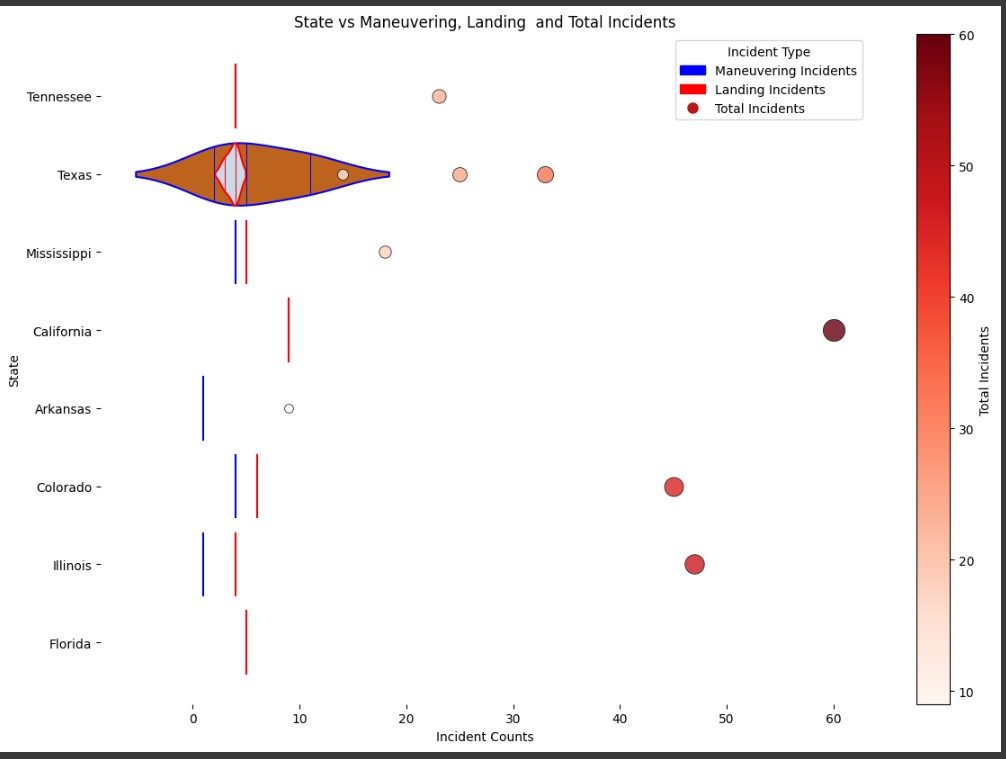

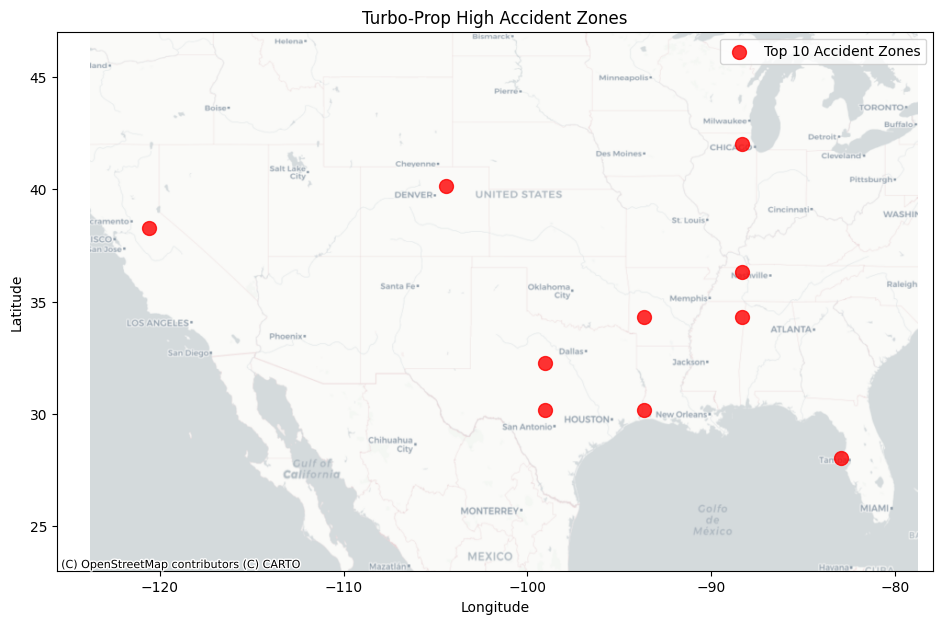

In [103]:
display(HTML("""
<div id="myDiv" style="background-color: blue; color: white; padding: 10px;">
    <div style="text-align: center;"><h1>Executive Summary</h1></div><br>
    The analysis examines Turbo Prop Airplane incidents in the Unitesd States. Using the incident report data from NTSB, we narrowed it down to the top 10 locations by incident count. <br>
    The data set is from January 1st 2000 to present. The data provides insights into high risks base don operational phases. The chart below allows us to see that Texas leads in at least three categories, total incidents, <br>
    maneuvering error incidents and landing insidents.  The chart also highlights other states with higher risks in diffrent operational phases. Thin vertical lines suggest limited incidend occurences. However, it is still worth <br>
    noting that these states represent the top 10 cities by total incident count. Three distinct analysis are displayed in the chart. Two violin plots represent maneuvering incidents (blue) and landing insidents (red). The scatter plot, overlayed on <br>
    the other plots, represents the total incident by state. States like Florida and Illinois have zero or one manuevering incidents but they total incident count keeps them in the top 10. This suggests that other operation phase risks exist. <br>
    The map below the chart, gives us a visual representation of the top 10 cities with highest incident count.
    <br><br><br>

</div>
"""))

# Get the path to the current notebook's directory in Google Drive
notebook_path = '/content/drive/My Drive/SpringBoard/Data Files' # os.getcwd()
image_path = os.path.join(notebook_path, 'state_vs_maneuvering-landing-total_incidents.jpg')

try:
    with open(image_path, "rb") as file:
        image = file.read()
    display(Image(data=image))
except FileNotFoundError:
    print(f"Error: Image file not found at '{image_path}'. Please ensure the filename is correct and the image is in the same directory as your notebook on Google Drive.")

plot_top_accident_zones(top_10_gdf, title="Turbo-Prop High Accident Zones")






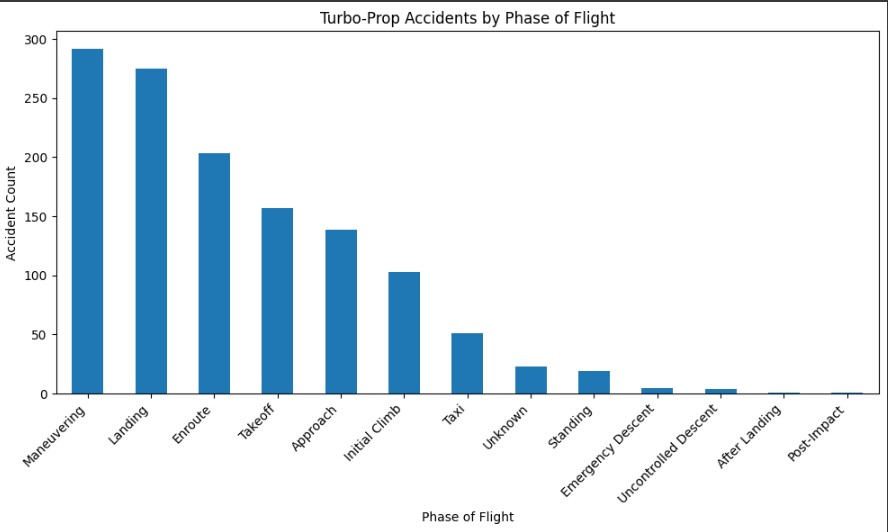

,State,Total_Maneuvering_Incidents,Maneuvering_Percentage,Total_Landing_Incidents,Landing_Percentage,State_Total_Incidents
0,Arkansas,1.0,11.11 %,0,0.00 %,9
4,Illinois,1.0,2.13 %,4,8.51 %,47
2,Colorado,4.0,8.89 %,6,13.33 %,45
1,California,9.0,15.00 %,9,15.00 %,60
7,Texas,18.0,25.00 %,11,15.28 %,72
6,Tennessee,4.0,17.39 %,4,17.39 %,23
3,Florida,0.0,0.00 %,5,25.00 %,20
5,Mississippi,4.0,22.22 %,5,27.78 %,18


In [119]:
display(HTML("""
<div id="myDiv" style="background-color: blue; color: white; padding: 10px;">
    <div style="text-align: center;"><h1>Data Analysys and Insights</h1></div><br>
    Incident data was processed from NTSB to undderstand an dextract data related to turbo-prop airplanes and incidents in search of any patterns or indications where potential future operational improvement can be made.<br>
    The initial data, narrowed to the United States, was scattered across the country. There were no obvious trends without diving deeper.<br><br>
    To further explore the data, we looked at accidents by operational phases aggregated by state, plot 1. This reveled that maneuvering and landing were the top two phases where accidents occured the most. <br>
    This does not mean that all state exhibit these two phases as the top two. For example, In Hot Springs Arkansas and West Chicago Illinois, these phases were not in the top two. While Texas leads in all category count,<br>
    Mississippi has the highest landing inident by percentage. Furthermore we note that a higher menuvering incident in a starte does not always mean a higher landing incident in the same state. <br> <br>

    The findings suggested additional information is needed to isolate other factors that contribute to the incidents during each phase of the flight. Do terrain and weather play a part? <br>
    Is Arkansas' maneuvering incident percentage correlated to the state terrain profile? Is California's 15% landing incident indicative of the frequent coastal fog?   <br><br>
    Further analysis is needed.

    <br><br><br>

</div>
"""))

# Get the path to the current notebook's directory in Google Drive
notebook_path = '/content/drive/My Drive/SpringBoard/Data Files' # os.getcwd()
image_path = os.path.join(notebook_path, 'Turbo-Prop Accidents by Phase.jpg')

try:
    with open(image_path, "rb") as file:
        image = file.read()
    display(Image(data=image))
except FileNotFoundError:
    print(f"Error: Image file not found at '{image_path}'. Please ensure the filename is correct and the image is in the same directory as your notebook on Google Drive.")


state_level_lan_sorted





### Markdown for future analysis as needed
city_a_name = "Denver"
city_b_name = "Chicago"

city_a_coords = get_city_coordinates(tpa_data, city_a_name)
city_b_coords = get_city_coordinates(tpa_data, city_b_name)

if city_a_coords and city_b_coords:
     Create GeoDataFrame from tpa_data
    geometry = [Point(xy) for xy in zip(tpa_data['Longitude'], tpa_data['Latitude'])]
    tpa_gdf_4326 = gpd.GeoDataFrame(tpa_data, geometry=geometry, crs='EPSG:4326')

     Define CRS values.
    denver_crs = 'EPSG:26913' #UTM zone 13N
    chicago_crs = 'EPSG:26916' #UTM zone 16N

    distance_a_miles = calculate_distances(tpa_gdf_4326, city_a_coords, denver_crs)
    distance_b_miles = calculate_distances(tpa_gdf_4326, city_b_coords, chicago_crs)

     Filter by distance (100 miles)
    region_a_data = tpa_gdf_4326[distance_a_miles <= 100]
    region_b_data = tpa_gdf_4326[distance_b_miles <= 100]

    # Now, analyze phase of flight for the filtered regions
    region_a_phase_counts = region_a_data['BroadPhaseofFlight'].value_counts()
    region_b_phase_counts = region_b_data['BroadPhaseofFlight'].value_counts()

    print("Phase of Flight Counts - Region A (100 miles):\n", region_a_phase_counts)
    print("\nPhase of Flight Counts - Region B (100 miles):\n", region_b_phase_counts)

     Visualization code (as before)
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    region_a_phase_counts.plot(kind='bar')
    plt.title(f"Region A ({city_a_name}, 100 miles) - Phase of Flight")
    plt.xlabel("Phase")
    plt.ylabel("Count")

    plt.subplot(1, 2, 2)
    region_b_phase_counts.plot(kind='bar')
    plt.title(f"Region B ({city_b_name}, 100 miles) - Phase of Flight")
    plt.xlabel("Phase")
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()
else:
    print("One or both cities were not found in the dataset.")